# Modeling approaches

# Model comparison

In [ ]:
%pip install numpy
%pip install pandas
%pip install scikit-learn
%pip install matplotlib
%pip install seaborn
%pip install statsmodels


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

from app import ingest

%matplotlib inline

In [17]:
TRAIN_DATA_FOLDER_PATH = "cs-train"
PRODUCTION_DATA_FOLDER_PATH = "cs-production"
PROCESSED_REVENUE_DATA_FILEPATH = "processed_revenue_data.csv"
train_size = 0.6


In [18]:
df = ingest.ingest_data([TRAIN_DATA_FOLDER_PATH], PROCESSED_REVENUE_DATA_FILEPATH, 10)
df.head()

Found 21 JSON files across 1 folders: ['cs-train']
Selecting top 10 ...
Top 10 countries by revenue: ['United Kingdom', 'EIRE', 'Germany', 'Norway', 'France', 'Hong Kong', 'Singapore', 'Portugal', 'Netherlands', 'Belgium']
Processed data saved to 'processed_revenue_data.csv'.


,year,month,country,revenue,times_viewed,date
0,2017,11,Belgium,130.00,1.0,2017-11-01
1,2017,11,EIRE,570.21,737.0,2017-11-01
2,2017,11,France,352.42,704.0,2017-11-01
3,2017,11,Germany,156.48,374.0,2017-11-01
4,2017,11,Netherlands,49.33,240.0,2017-11-01


In [19]:
months = df['date'].unique()
total_months = len(months)
train_months = round(total_months * train_size)
test_months = total_months - train_months
print(train_months, test_months)

10 7


In [20]:
# Add lagged revenue (1-month)
df['revenue_lag1'] = df.groupby('country')['revenue'].shift(1)

# Encode country for Random Forest
label_encoder = LabelEncoder()
df['country_encoded'] = label_encoder.fit_transform(df['country'])

# Train-test split (time-based)
df = df.sort_values('date')
unique_dates = df['date'].unique()
train_dates = unique_dates[:train_months]
test_dates = unique_dates[train_months:train_months + test_months]
train_df = df[df['date'].isin(train_dates)]
test_df = df[df['date'].isin(test_dates)]

# Check data
print("Train Data Shape:", train_df.shape)
print("Test Data Shape:", test_df.shape)
print("Train Date Range:", train_df['date'].min(), "to", train_df['date'].max())
print("Test Date Range:", test_df['date'].min(), "to", test_df['date'].max())

# Top 10 countries (for evaluation)
country_revenue = train_df.groupby('country')['revenue'].sum().sort_values(ascending=False)
top_10 = country_revenue.head(10).index
print("\nTop 10 Countries:", list(top_10))

Train Data Shape: (80, 8)
Test Data Shape: (60, 8)
Train Date Range: 2017-11-01 00:00:00 to 2018-10-01 00:00:00
Test Date Range: 2018-11-01 00:00:00 to 2019-07-01 00:00:00

Top 10 Countries: ['United Kingdom', 'EIRE', 'Norway', 'Germany', 'France', 'Hong Kong', 'Netherlands', 'Belgium', 'Portugal', 'Singapore']


## Baseline Model (Last Value Persistence)

In [21]:
# Baseline: Last value persistence
baseline_predictions = test_df[['date', 'country', 'revenue']].copy()
baseline_predictions['pred_revenue'] = np.nan

# Get last training value per country
last_values = train_df.groupby('country').last()[['date', 'revenue']].rename(columns={'revenue': 'last_revenue'})
for country in baseline_predictions['country'].unique():
    if country in last_values.index:
        baseline_predictions.loc[baseline_predictions['country'] == country, 'pred_revenue'] = last_values.loc[country, 'last_revenue']
    else:
        print(f"No training data for {country}, using 0.")
        baseline_predictions.loc[baseline_predictions['country'] == country, 'pred_revenue'] = 0

# Total revenue predictions
baseline_total = baseline_predictions.groupby('date')['pred_revenue'].sum()
baseline_total_actual = test_df.groupby('date')['revenue'].sum()

# Print sample predictions
print("Baseline Sample Predictions:")
print(baseline_predictions.head(10))

Baseline Sample Predictions:
         date         country     revenue  pred_revenue
87 2018-11-01  United Kingdom  313246.222     243017.00
86 2018-11-01        Portugal     816.860        556.99
85 2018-11-01          Norway     455.230         65.76
84 2018-11-01     Netherlands    1156.570        754.57
83 2018-11-01         Germany    3788.380       3264.75
82 2018-11-01          France    3161.510       1968.79
81 2018-11-01            EIRE    5235.610      20010.97
80 2018-11-01         Belgium     779.760        387.89
88 2019-02-01         Belgium     645.040        387.89
89 2019-02-01            EIRE    1302.300      20010.97


## ARIMA with Aggregation

In [22]:
# Initialize results
arima_predictions = test_df[['date', 'country', 'revenue']].copy()
arima_predictions['pred_revenue'] = np.nan
countries = train_df['country'].unique()

# Train ARIMA per country
for country in countries:
    # Get country data
    country_train = train_df[train_df['country'] == country][['date', 'revenue']].set_index('date')
    country_test = test_df[test_df['country'] == country][['date', 'revenue']].set_index('date')
    
    # Skip if insufficient data (<6 months)
    if len(country_train) < 6:
        print(f"Skipping {country}: Only {len(country_train)} months.")
        continue
    
    # Ensure monthly frequency
    country_train = country_train.asfreq('MS', fill_value=0)
    
    # Fit ARIMA
    try:
        model = ARIMA(country_train['revenue'], order=(1,1,1), seasonal_order=(0,0,0,12))
        model_fit = model.fit()
        
        # Predict for test period
        test_len = len(country_test)
        if test_len > 0:
            pred = model_fit.forecast(steps=test_len)
            arima_predictions.loc[(arima_predictions['country'] == country) & 
                                (arima_predictions['date'].isin(country_test.index)), 'pred_revenue'] = pred.values
    except Exception as e:
        print(f"ARIMA failed for {country}: {e}")
        continue

# Total revenue predictions
arima_total = arima_predictions.groupby('date')['pred_revenue'].sum()
arima_total_actual = test_df.groupby('date')['revenue'].sum()

# Print sample predictions
print("ARIMA Sample Predictions:")
print(arima_predictions.head(10))

Skipping Norway: Only 4 months.
Skipping Hong Kong: Only 4 months.
Skipping Singapore: Only 2 months.
ARIMA Sample Predictions:
         date         country     revenue   pred_revenue
87 2018-11-01  United Kingdom  313246.222  216748.629179
86 2018-11-01        Portugal     816.860     355.463117
85 2018-11-01          Norway     455.230            NaN
84 2018-11-01     Netherlands    1156.570     665.040131
83 2018-11-01         Germany    3788.380    2944.111312
82 2018-11-01          France    3161.510    2090.925556
81 2018-11-01            EIRE    5235.610   31869.613653
80 2018-11-01         Belgium     779.760     499.456733
88 2019-02-01         Belgium     645.040     487.640513
89 2019-02-01            EIRE    1302.300   43728.256663


## Random Forest Regressor

In [23]:
# Features for Random Forest
features = ['country_encoded', 'month', 'year', 'times_viewed', 'revenue_lag1']
X_train = train_df[features].fillna(0)  # Fill NaN lags with 0
y_train = train_df['revenue']
X_test = test_df[features].fillna(0)
y_test = test_df['revenue']

# Train model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
rf_predictions = test_df[['date', 'country', 'revenue']].copy()
rf_predictions['pred_revenue'] = rf_model.predict(X_test)

# Total revenue predictions
rf_total = rf_predictions.groupby('date')['pred_revenue'].sum()
rf_total_actual = test_df.groupby('date')['revenue'].sum()

# Feature importance
feature_importance = pd.Series(rf_model.feature_importances_, index=features)
print("Random Forest Feature Importance:")
print(feature_importance.sort_values(ascending=False))

# Print sample predictions
print("\nRandom Forest Sample Predictions:")
print(rf_predictions.head(10))

Random Forest Feature Importance:
revenue_lag1       0.825923
country_encoded    0.137444
month              0.032951
times_viewed       0.003660
year               0.000022
dtype: float64

Random Forest Sample Predictions:
         date         country     revenue   pred_revenue
87 2018-11-01  United Kingdom  313246.222  156688.831530
86 2018-11-01        Portugal     816.860     474.765975
85 2018-11-01          Norway     455.230     860.103294
84 2018-11-01     Netherlands    1156.570     755.160467
83 2018-11-01         Germany    3788.380    3124.711247
82 2018-11-01          France    3161.510    2747.746111
81 2018-11-01            EIRE    5235.610   13898.934300
80 2018-11-01         Belgium     779.760     444.488952
88 2019-02-01         Belgium     645.040    2249.820810
89 2019-02-01            EIRE    1302.300    2587.643225


# Evaluation

In [24]:
# Per-country metrics
def compute_metrics(actual, predicted, name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    return {'Model': name, 'RMSE': rmse, 'MAE': mae}

# Baseline metrics
baseline_valid = baseline_predictions.dropna()
baseline_metrics = compute_metrics(baseline_valid['revenue'], baseline_valid['pred_revenue'], 'Baseline')

# ARIMA metrics
arima_valid = arima_predictions.dropna()
arima_metrics = compute_metrics(arima_valid['revenue'], arima_valid['pred_revenue'], 'ARIMA')

# Random Forest metrics
rf_metrics = compute_metrics(rf_predictions['revenue'], rf_predictions['pred_revenue'], 'Random Forest')

# Total revenue metrics
def total_error(actual, predicted, name):
    ape = np.abs(predicted.sum() - actual.sum()) / actual.sum() * 100
    return {'Model': name, 'Total Revenue APE (%)': ape}

baseline_total_metrics = total_error(baseline_total_actual, baseline_total, 'Baseline')
arima_total_metrics = total_error(arima_total_actual, arima_total, 'ARIMA')
rf_total_metrics = total_error(rf_total_actual, rf_total, 'Random Forest')

# Top 10 countries metrics
baseline_top10 = baseline_valid[baseline_valid['country'].isin(top_10)]
arima_top10 = arima_valid[arima_valid['country'].isin(top_10)]
rf_top10 = rf_predictions[rf_predictions['country'].isin(top_10)]
baseline_top10_metrics = compute_metrics(baseline_top10['revenue'], baseline_top10['pred_revenue'], 'Baseline (Top 10)')
arima_top10_metrics = compute_metrics(arima_top10['revenue'], arima_top10['pred_revenue'], 'ARIMA (Top 10)')
rf_top10_metrics = compute_metrics(rf_top10['revenue'], rf_top10['pred_revenue'], 'Random Forest (Top 10)')

# Combine metrics
metrics_df = pd.DataFrame([baseline_metrics, arima_metrics, rf_metrics])
total_metrics_df = pd.DataFrame([baseline_total_metrics, arima_total_metrics, rf_total_metrics])
top10_metrics_df = pd.DataFrame([baseline_top10_metrics, arima_top10_metrics, rf_top10_metrics])

print("\nPer-Country Metrics:")
print(metrics_df)
print("\nTotal Revenue Metrics:")
print(total_metrics_df)
print("\nTop 10 Countries Metrics:")
print(top10_metrics_df)


Per-Country Metrics:
           Model          RMSE           MAE
0       Baseline  32548.109363  13317.117167
1          ARIMA  37295.562138  19209.401419
2  Random Forest  23917.074889   7766.109333

Total Revenue Metrics:
           Model  Total Revenue APE (%)
0       Baseline              45.687909
1          ARIMA              53.360670
2  Random Forest               5.125549

Top 10 Countries Metrics:
                    Model          RMSE           MAE
0       Baseline (Top 10)  32548.109363  13317.117167
1          ARIMA (Top 10)  37295.562138  19209.401419
2  Random Forest (Top 10)  23917.074889   7766.109333


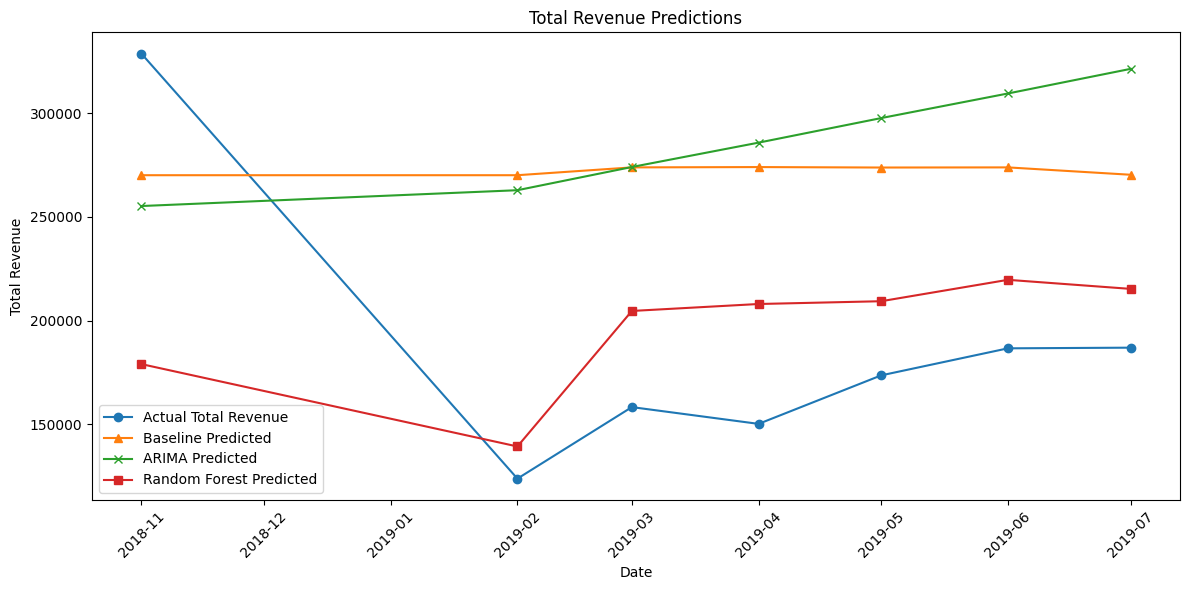

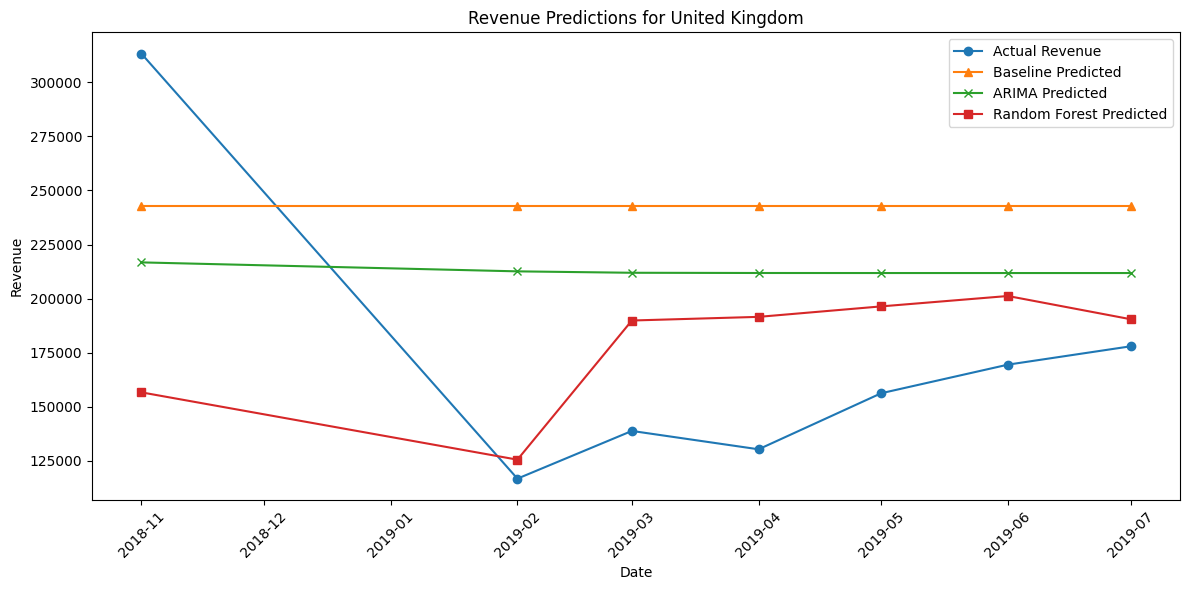

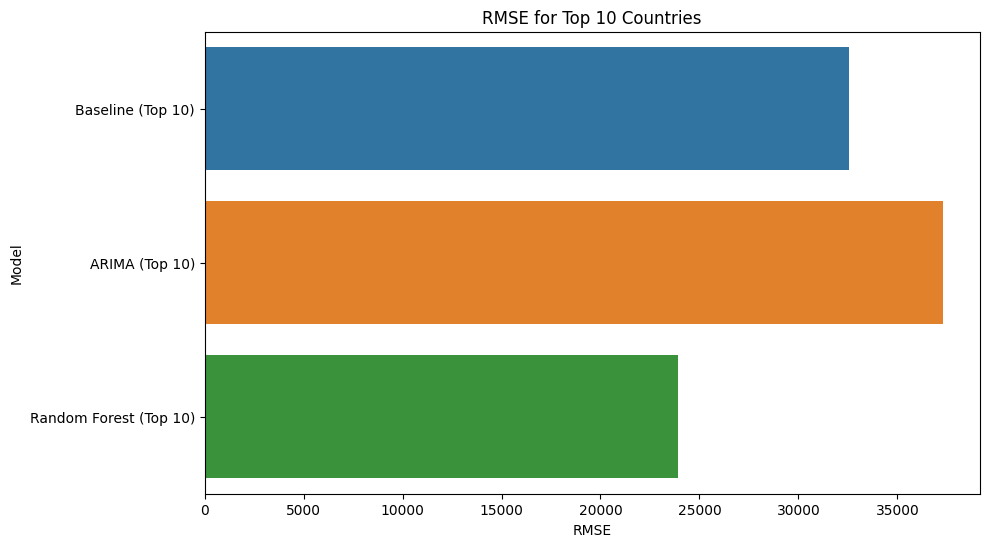

In [25]:
# Plot total revenue predictions
plt.figure(figsize=(12, 6))
plt.plot(baseline_total_actual.index, baseline_total_actual.values, label='Actual Total Revenue', marker='o')
plt.plot(baseline_total.index, baseline_total.values, label='Baseline Predicted', marker='^')
plt.plot(arima_total.index, arima_total.values, label='ARIMA Predicted', marker='x')
plt.plot(rf_total.index, rf_total.values, label='Random Forest Predicted', marker='s')
plt.title("Total Revenue Predictions")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot sample country (top country)
sample_country = top_10[0]
baseline_country = baseline_predictions[baseline_predictions['country'] == sample_country]
arima_country = arima_predictions[arima_predictions['country'] == sample_country]
rf_country = rf_predictions[rf_predictions['country'] == sample_country]
actual_country = test_df[test_df['country'] == sample_country]
plt.figure(figsize=(12, 6))
plt.plot(actual_country['date'], actual_country['revenue'], label='Actual Revenue', marker='o')
plt.plot(baseline_country['date'], baseline_country['pred_revenue'], label='Baseline Predicted', marker='^')
plt.plot(arima_country['date'], arima_country['pred_revenue'], label='ARIMA Predicted', marker='x')
plt.plot(rf_country['date'], rf_country['pred_revenue'], label='Random Forest Predicted', marker='s')
plt.title(f"Revenue Predictions for {sample_country}")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Bar plot for top 10 metrics
plt.figure(figsize=(10, 6))
sns.barplot(x='RMSE', y='Model', data=top10_metrics_df, hue='Model')
plt.title("RMSE for Top 10 Countries")
plt.xlabel("RMSE")
plt.show()

## Model selection

Best model:

In [26]:
rmse_top10 = top10_metrics_df.set_index('Model')['RMSE']
best_model = rmse_top10.idxmin()
best_model


'Random Forest (Top 10)'